# 基于 DH 模型的关节目标求解与实机驱动

借助 `roboticstoolbox` 在内存里搭出 DFbot 的运动学模型,支持两种目标输入方式,
得到关节模型角后做仿真渲染并(可选)下发到一体化关节。

输入方式:
- `target_kind = 'joint'` :直接给六个关节模型角 `joint_target_deg`
- `target_kind = 'xyz'`   :给末端 DH 帧原点的笛卡尔坐标 `tcp_xyz_mm`,经 `ikine_LM` 反解

工作流程:先看仿真姿态、关节角与 FK 结果是否合理;确认无误后再把
`execute_on_hardware` 改成 True,连同串口配置一起把指令发到机械臂。

提醒:这里的笛卡尔点是 DH 末端帧原点,不一定是夹爪 TCP;若用夹爪尖为基准,需要单独引入 TCP 偏置。

ikine_LM success  = True
ikine_LM reason   = Success
ikine_LM residual = 1.523037515524359e-10

求解来源       : ikine_LM 从 xyz 求解
关节模型角(度) = [-1.04, 3.25, 84.95, 45.648, -19.075, 0.0]
FK 末端坐标 mm = [100.0, 21.94, 200.0]
输入目标 mm    = [100, 21.94, 200]
坐标偏差 mm    = [-0.0, -0.0, -0.0]
齐次变换矩阵 :
[[-0.6755  0.6926 -0.2528  0.1   ]
 [ 0.3391 -0.0126 -0.9407  0.0219]
 [-0.6547 -0.7212 -0.2264  0.2   ]
 [ 0.      0.      0.      1.    ]]


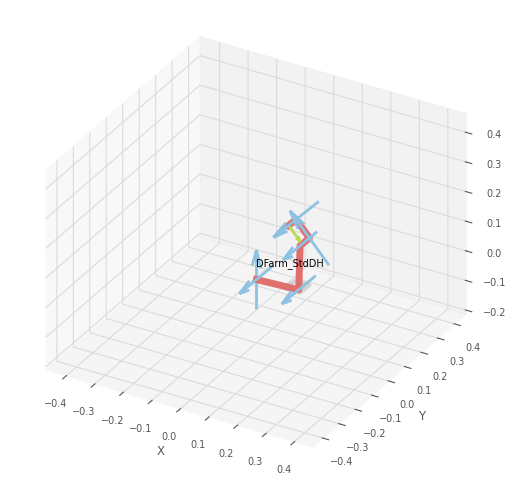

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'DFarm_StdDH')

<Figure size 640x480 with 0 Axes>

In [ ]:
# ---- 把存放 arm_robot.py 的目录加入 sys.path,使 import 可达 -----------------
import os, sys
_search_root = os.path.abspath(os.getcwd())
for _ in range(5):
    if os.path.isfile(os.path.join(_search_root, 'arm_robot.py')):
        if _search_root not in sys.path:
            sys.path.insert(0, _search_root)
        break
    _search_root = os.path.dirname(_search_root)
else:
    raise ImportError('未在最近 5 层父目录中定位到 arm_robot.py;请在 daran/ 或其子目录下打开本笔记本')
# ----------------------------------------------------------------------------
import time
import numpy as np
from roboticstoolbox import DHRobot, RevoluteDH
from spatialmath import SE3
import arm_robot as robot

np.set_printoptions(precision=4, suppress=True)

# ============================================================
# 1) 目标设置
# ============================================================
target_kind = 'xyz'                       # 'joint' 或 'xyz'

# joint 模式下使用:六个关节模型角(度),依次对应 q1..q6
joint_target_deg = [20, 0, 0, 0, 0, 0]

# xyz 模式下使用:末端 DH 帧原点的笛卡尔目标(mm)
tcp_xyz_mm = [100, 21.94, 200]   # y=21.94 是 park 姿态 J1=0 时 EE 的自然平面;留在此平面内 IK 无须转底座 yaw

# 是否仅约束位置(忽略 R/P/Y);为 False 时同时强制末端姿态
ignore_orientation = True
tcp_rpy_deg        = [0, 0, 0]
euler_convention   = 'zyx'

# 反解的初值(度)。位置-only 解非唯一,初值会决定落到哪个分支。
ik_seed_deg = [0, 0, 0, 0, 0, 0]

# 串口与波特率(Linux 实测 /dev/ttyACM2,Windows 通常为 'COM4' 等)
can_bridge_port = '/dev/ttyACM0'
serial_baud     = 115200

# 实机执行开关:先以 False 跑一遍仿真,确认后再开启
execute_on_hardware = False
joint_speed_rpm     = 1.0

# 当前所用的关节模型角范围(度)。会同时供 RTB 的 qlim 与 arm_robot 使用
qmin_deg = [-160, -10, -160, -160, -180, -180]
qmax_deg = [ 160, 180,  160,  160,  180,  180]

# 桌面保护:DH 基坐标系下,所有关节坐标系原点的 z 不得低于该阈值(m)
# 0 表示桌面与零位姿态齐平;若基座装在抬高支架上,可改成负值放宽
desk_z_min_m = 0.0


# ============================================================
# 2) 模型搭建与辅助函数
# ============================================================
LINK_PARAMS = (
    dict(alpha=np.pi/2),
    dict(a=0.15),
    dict(a=0.15),
    dict(d=-0.05494, alpha=np.pi/2, offset=np.pi/2),
    dict(d=0.068,    alpha=-np.pi/2),
    dict(d=0.033),
)


def make_dfarm():
    """按当前 DH 表与限位组装一个 RTB 的 DHRobot 实例。"""
    links = [
        RevoluteDH(qlim=np.deg2rad([qmin_deg[i], qmax_deg[i]]), **kw)
        for i, kw in enumerate(LINK_PARAMS)
    ]
    return DHRobot(links, name='DFarm_StdDH')


def verify_within_limits(angles_deg):
    """任一关节越界则抛出 ValueError,并打印越界关节及边界值。"""
    arr = np.asarray(angles_deg, dtype=float)
    lo  = np.asarray(qmin_deg,    dtype=float)
    hi  = np.asarray(qmax_deg,    dtype=float)
    bad = np.flatnonzero((arr < lo) | (arr > hi))
    if bad.size:
        problems = '; '.join(
            f'J{i+1}: {arr[i]:+.2f}° not in [{lo[i]:+.2f}, {hi[i]:+.2f}]'
            for i in bad
        )
        raise ValueError(f'关节模型角越界 -> {problems}')


def verify_above_desk(q_rad, dfarm, z_min=None):
    """桌面保护:所有 DH 中间坐标系原点的 z 必须 >= z_min(m),否则抛 ValueError。

    保守近似——只看每个关节坐标系原点位置,不做杆件中段扫描。对常见构型
    (避免肘部/腕部下扎)足够。F0 是基座,固定在原点,跳过。
    """
    if z_min is None:
        z_min = desk_z_min_m
    frames = dfarm.fkine_all(q_rad)
    below = [(i, float(frames[i].t[2]))
             for i in range(1, len(frames))
             if float(frames[i].t[2]) < z_min - 1e-9]
    if below:
        detail = '; '.join(f'F{i}: z={z*1000:+.1f}mm' for i, z in below)
        raise ValueError(
            f'存在关节坐标系 z 低于桌面安全线 (< {z_min*1000:+.0f} mm) -> {detail}'
        )


def pose_from_xyz():
    """将 tcp_xyz_mm/(可选)tcp_rpy_deg 拼成 SE3 目标位姿。"""
    pose = SE3.Trans(np.asarray(tcp_xyz_mm, dtype=float) * 1e-3)
    if not ignore_orientation:
        pose = pose * SE3.RPY(tcp_rpy_deg, unit='deg', order=euler_convention)
    return pose


def compute_joint_target(dfarm):
    """按 target_kind 分派,返回最终关节模型角(度)与求解来源说明。"""
    if target_kind == 'joint':
        q = np.asarray(joint_target_deg, dtype=float)
        verify_within_limits(q)
        verify_above_desk(np.deg2rad(q), dfarm)
        return q, 'joint mode (直接输入)'

    if target_kind != 'xyz':
        raise ValueError("target_kind 只能取 'joint' 或 'xyz'")

    target_pose = pose_from_xyz()
    seed_rad    = np.deg2rad(np.asarray(ik_seed_deg, dtype=float))
    dof_mask    = [1, 1, 1, 0, 0, 0] if ignore_orientation else [1] * 6

    ik = dfarm.ikine_LM(
        target_pose,
        q0=seed_rad,
        mask=dof_mask,
        ilimit=100,
        slimit=100,
        joint_limits=True,
    )
    print('ikine_LM success  =', ik.success)
    print('ikine_LM reason   =', getattr(ik, 'reason', ''))
    print('ikine_LM residual =', getattr(ik, 'residual', None))
    if not ik.success:
        raise RuntimeError('反解失败:可调整 tcp_xyz_mm / ik_seed_deg / qmin_deg, qmax_deg 或姿态约束')

    q_deg = np.rad2deg(ik.q)
    verify_within_limits(q_deg)
    verify_above_desk(ik.q, dfarm)
    return q_deg, 'ikine_LM 从 xyz 求解'


def query_joint_state(arm):
    """读电机角并转换成模型角;任一关节读取失败时返回 (False, False)。"""
    raw = arm.read_joints()
    if raw is False:
        return False, False
    return raw, arm.servo_to_model(raw)


# ============================================================
# 3) 求解 -> 打印 -> 仿真渲染
# ============================================================
dfarm           = make_dfarm()
q_deg, source   = compute_joint_target(dfarm)
q_rad           = np.deg2rad(q_deg)

T_now    = dfarm.fkine(q_rad)
T_matrix = np.asarray(T_now.A if hasattr(T_now, 'A') else T_now)
position = T_matrix[:3, 3] * 1000

print('\n求解来源       :', source)
print('关节模型角(度) =', np.round(q_deg, 3).tolist())
print('FK 末端坐标 mm =', np.round(position, 3).tolist())
if target_kind == 'xyz':
    delta = position - np.asarray(tcp_xyz_mm, dtype=float)
    print('输入目标 mm    =', tcp_xyz_mm)
    print('坐标偏差 mm    =', np.round(delta, 4).tolist())
print('齐次变换矩阵 :')
print(T_matrix)

# 实机控制单元会引用这个变量
commanded_q_deg = q_deg.tolist()

# ============================================================
# 4) 仿真轨迹:park 姿态线性插值到 IK 解,生成动画与诊断图
# ============================================================
# 以安全 park 姿态 [0, 90, 0, 0, 0, 0] 为起点,关节空间线性插到 IK 解 q_rad;
# 实际硬件 set_arm_joints() 内部走梯形剖面到位,这里的等分插值仅供仿真观察轨迹形状。
animation_filename   = 'single_target_anim.gif'
final_frame_filename = 'single_target_final.png'
joint_plot_filename  = 'single_target_joints.png'
n_frames        = 40
start_q_rad     = np.deg2rad([0, 90, 0, 0, 0, 0])     # park 起点
joint_traj_rad  = np.linspace(start_q_rad, q_rad, n_frames)
joint_traj_deg  = np.rad2deg(joint_traj_rad)
ee_traj_mm      = np.asarray([dfarm.fkine(_q).t * 1000 for _q in joint_traj_rad])

# ---- 3D 动画:含 EE 路径覆盖 + 起止标注 ----
from roboticstoolbox.backends.PyPlot import PyPlot
env = PyPlot()
env.launch(name='Single-Target Trajectory',
           limits=[-0.30, 0.30, -0.30, 0.30, -0.10, 0.45])
env.add(dfarm)
_ee_m = ee_traj_mm / 1000.0
env.ax.plot(_ee_m[:, 0], _ee_m[:, 1], _ee_m[:, 2],
            color='red', linewidth=2.0, alpha=0.9, label='EE trajectory')
env.ax.scatter([_ee_m[0, 0]], [_ee_m[0, 1]], [_ee_m[0, 2]],
               color='limegreen', s=80, marker='o', label='start (park)')
env.ax.scatter([_ee_m[-1, 0]], [_ee_m[-1, 1]], [_ee_m[-1, 2]],
               color='magenta', s=80, marker='X', label='target')
env.ax.legend(loc='upper left', fontsize=8)

_frames = []
for _q in joint_traj_rad:
    dfarm.q = _q
    env.step(0.05)
    _frames.append(env.getframe())
_frames[0].save(animation_filename, save_all=True,
                append_images=_frames[1:], optimize=False,
                duration=80, loop=0)
# 终态:保存当前 3D 图(已含 EE 路径)为静态 PNG
env.fig.savefig(final_frame_filename, dpi=150, bbox_inches='tight')

# ---- 关节角随帧曲线:6 条线一起画,直观看到每个关节的运动量级 ----
import matplotlib.pyplot as _plt
_fig, _ax = _plt.subplots(figsize=(8, 4.5))
for _j in range(6):
    _ax.plot(range(n_frames), joint_traj_deg[:, _j],
             label=f'J{_j+1}', linewidth=1.5)
_ax.set_xlabel('frame index (0 = park, {} = target)'.format(n_frames - 1))
_ax.set_ylabel('joint model angle (deg)')
_ax.set_title('Joint trajectory: park -> IK target')
_ax.grid(True, alpha=0.3)
_ax.legend(loc='best', fontsize=9, ncol=3)
_fig.tight_layout()
_fig.savefig(joint_plot_filename, dpi=150, bbox_inches='tight')
_plt.close(_fig)

print('仿真轨迹动画 :', animation_filename)
print('终态静态图   :', final_frame_filename)
print('关节角曲线   :', joint_plot_filename)
print('park -> 目标 每关节净位移 deg :',
      np.round(joint_traj_deg[-1] - joint_traj_deg[0], 3).tolist())

## 实机执行:把求出的关节角下发

确认上面的仿真姿态、关节角和 FK 坐标都合理后,把第一个 cell 里的
`execute_on_hardware` 改成 True,再运行下面这段。

In [5]:
if not execute_on_hardware:
    print('execute_on_hardware = False,未发送实机命令。'
          '确认仿真和角度后改成 True 再跑本 cell。')
else:
    verify_within_limits(commanded_q_deg)
    verify_above_desk(np.deg2rad(commanded_q_deg), dfarm)

    arm = robot.arm_robot(
        L_p             = 0,
        L_p_mass_center = 0,
        MAX_list_temp   = qmax_deg,
        MIN_list_temp   = qmin_deg,
        G_p             = 0,
        com             = can_bridge_port,
        uart_baudrate   = serial_baud,
    )

    raw_before, model_before = query_joint_state(arm)
    print('运动前 servo =', raw_before)
    print('运动前 model =', model_before)
    if model_before is False:
        raise RuntimeError('读取当前关节角失败,中止运动。')

    print('目标 model deg =', np.round(commanded_q_deg, 3).tolist())
    sent_ok = arm.set_arm_joints(angle_list=commanded_q_deg, speed=joint_speed_rpm)
    print('指令下发结果   =', sent_ok)
    if sent_ok is False:
        raise RuntimeError('set_arm_joints 返回 False,目标未执行。')

    arm.pose_done()
    time.sleep(0.5)

    raw_after, model_after = query_joint_state(arm)
    print('运动后 servo =', raw_after)
    print('运动后 model =', model_after)

    if model_after is not False:
        T_done     = dfarm.fkine(np.deg2rad(model_after))
        T_done_arr = np.asarray(T_done.A if hasattr(T_done, 'A') else T_done)
        print('回读模型角对应的 FK 末端 mm =',
              np.round(T_done_arr[:3, 3] * 1000, 3).tolist())

位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
初始化成功
运动前 servo = [0.00042110681533813477, -90.0042495727539, 0.0039958953857421875, 0.0066347126848995686, 0.0038752558175474405, 0.004830121994018555]
运动前 model = [0.0, 90.0, 0.0, -0.0, 0.0, 0.0]
目标 model deg = [-1.04, 3.25, 84.95, 45.648, -19.075, 0.0]
指令下发结果   = True
运动后 servo = [-1.04222869

## 可选:回到安全竖直 park 姿态

机械臂参数零位 `[0, 0, 0, 0, 0, 0]` 在物理上是**水平全展**——前臂贴着桌面伸出去,
撞桌风险大,也占用大量水平空间。

更安全的"home"位是把 J2 抬到 +90°,让臂体竖直向上举起。

把 `request_home = True` 后运行下面 cell,机械臂会运动到 `[0, 90, 0, 0, 0, 0]`,
所有连杆原点都在 z >= 0,自动通过桌面保护。


In [10]:
request_home  = True
home_pose_deg = [0, 90, 0, 0, 0, 0]   # 安全竖直 park 姿态:J2=+90° 让臂体朝上

if not request_home:
    print('request_home = False,未发送回零命令。')
else:
    target = np.asarray(home_pose_deg, dtype=float)
    verify_within_limits(target)
    verify_above_desk(np.deg2rad(target), dfarm)
    arm = robot.arm_robot(
        L_p             = 0,
        L_p_mass_center = 0,
        MAX_list_temp   = qmax_deg,
        MIN_list_temp   = qmin_deg,
        G_p             = 0,
        com             = can_bridge_port,
        uart_baudrate   = serial_baud,
    )
    print('运动前 model =', query_joint_state(arm)[1])
    sent_ok = arm.set_arm_joints(angle_list=target.tolist(), speed=joint_speed_rpm)
    print('指令下发结果 =', sent_ok)
    arm.pose_done()
    time.sleep(0.5)
    print('运动后 model =', query_joint_state(arm)[1])

位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
初始化成功
运动前 model = [57.6, 1.5, 56.9, 30.3, -13.1, 0.1]
指令下发结果 = True
运动后 model = [-0.0, 90.0, -0.0, -0.0, -0.0, 0.0]
